# 

In [4]:

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded ✓")


Libraries loaded ✓


In [5]:
import geopandas as gpd


In [3]:
pip install numpy geopandas rasterio shapely matplotlib seabed scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping

In [40]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Paths (Jupyter Notebook Fix)
# ═══════════════════════════════════════════════════════════════
from pathlib import Path
import os

os.chdir(r"/Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events")

BASE_PATH = Path.cwd()

# Your GeoJSON ROI file  ← subfolder fixed
ROI_PATH = BASE_PATH / "hasdeo_qgis" / "qgic_features.geojson"

# Your 2 TIF files
TIFF_1 = BASE_PATH / "hasdeo_qgis"/ "MON_Hasdeo_Full_2020_01_first_event.tif"
TIFF_2 = BASE_PATH / "hasdeo_qgis"/ "MON_Hasdeo_Full_2017_03_pre_event.tif"

# Output folder
OUTPUT_DIR = BASE_PATH / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    0: "dense_forest",
    1: "farming",
    2: "mining",
    3: "water_body",
    4: "bare_soil",
}

print(f"Working dir  : {BASE_PATH}")
print(f"ROI file     : {ROI_PATH} | Exists: {ROI_PATH.exists()}")
print(f"TIFF 1       : {TIFF_1}   | Exists: {TIFF_1.exists()}")
print(f"TIFF 2       : {TIFF_2}   | Exists: {TIFF_2.exists()}")
print(f"Output       : {OUTPUT_DIR}")

Working dir  : /Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events
ROI file     : /Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events/hasdeo_qgis/qgic_features.geojson | Exists: True
TIFF 1       : /Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events/hasdeo_qgis/MON_Hasdeo_Full_2020_01_first_event.tif   | Exists: True
TIFF 2       : /Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events/hasdeo_qgis/MON_Hasdeo_Full_2017_03_pre_event.tif   | Exists: True
Output       : /Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events/output


In [28]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Load ROI and verify
# ═══════════════════════════════════════════════════════════════

roi = gpd.read_file(ROI_PATH)
print(f"Total polygons : {len(roi)}")
print(f"CRS            : {roi.crs}")
print(f"\nClass distribution:")
print(roi.groupby(["class_id", "class_name"]).size().reset_index(name="polygon_count"))


Total polygons : 52
CRS            : EPSG:32644

Class distribution:
   class_id    class_name  polygon_count
0         0  dense_forest              8
1         1       farming              3
2         2        Mining              1
3         2        mining             10
4         2       minning              2
5         3       farming              1
6         3    water_body             13
7         4     bare_soil             14


In [30]:
import geopandas as gpd

# Load the GeoJSON
gdf = gpd.read_file(ROI_PATH)

# Step 1: Normalize class_name (strip whitespace + lowercase)
gdf["class_name"] = gdf["class_name"].str.strip().str.lower()

# Step 2: Fix typo "minning" → "mining"
gdf["class_name"] = gdf["class_name"].replace("minning", "mining")

# Step 3: Reassign class_id based on corrected class_name
NAME_TO_ID = {
    "dense_forest": 0,
    "farming":      1,
    "mining":       2,
    "water_body":   3,
    "bare_soil":    4,
}
gdf["class_id"] = gdf["class_name"].map(NAME_TO_ID)

# Step 4: Verify
dist = (gdf.groupby(["class_id", "class_name"])
           .size()
           .reset_index(name="polygon_count"))
print("Class distribution:")
print(dist)

Class distribution:
   class_id    class_name  polygon_count
0         0  dense_forest              8
1         1       farming              4
2         2        mining             13
3         3    water_body             13
4         4     bare_soil             14


In [42]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Paths (Fixed)
# ═══════════════════════════════════════════════════════════════
from pathlib import Path
import os

os.chdir(r"/Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events")
BASE_PATH = Path.cwd()

ROI_PATH   = BASE_PATH / "hasdeo_qgis" / "qgic_features.geojson"
OUTPUT_DIR = BASE_PATH / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ✅ Must match exact class_name strings in your GeoJSON
CLASS_NAMES = {
    0: "dense_forest",
    1: "farming",
    2: "mining",
    3: "water_body",
    4: "bare_soil",
}

print(f"ROI    : {ROI_PATH}  | Exists: {ROI_PATH.exists()}")
print(f"TIFF 1 : {TIFF_1}   | Exists: {TIFF_1.exists()}")
print(f"TIFF 2 : {TIFF_2}   | Exists: {TIFF_2.exists()}")


# ═══════════════════════════════════════════════════════════════
# CELL 3 — Load & Clean ROI
# ═══════════════════════════════════════════════════════════════
import geopandas as gpd

roi = gpd.read_file(ROI_PATH)

# Fix typos and normalize
roi["class_name"] = roi["class_name"].str.strip().str.lower()
roi["class_name"] = roi["class_name"].replace("minning", "mining")

NAME_TO_ID = {v: k for k, v in CLASS_NAMES.items()}
roi["class_id"] = roi["class_name"].map(NAME_TO_ID)

# Drop any rows that didn't map correctly
bad = roi["class_id"].isna()
if bad.any():
    print(f"⚠️  Dropping {bad.sum()} rows with unrecognized class_name:")
    print(roi[bad]["class_name"].value_counts())
    roi = roi[~bad].copy()

roi["class_id"] = roi["class_id"].astype(int)

print(f"\nCRS : {roi.crs}")
print(f"Total polygons : {len(roi)}")
print(roi.groupby(["class_id", "class_name"]).size().reset_index(name="polygon_count"))


# ═══════════════════════════════════════════════════════════════
# CELL 4 — Extract Pixels (uint8 Fix)
# ═══════════════════════════════════════════════════════════════
import numpy as np
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping

def extract_pixels(tiff_path: Path, roi_gdf: gpd.GeoDataFrame):
    features, labels = [], []

    with rasterio.open(tiff_path) as src:
        print(f"  TIFF CRS    : {src.crs}")
        print(f"  TIFF dtype  : {src.dtypes}")
        print(f"  TIFF nodata : {src.nodata}")

        roi_reprojected = roi_gdf.to_crs(src.crs)

        for _, row in roi_reprojected.iterrows():
            geom     = [mapping(row.geometry)]
            class_id = int(row["class_id"])

            try:
                # ✅ No nodata= argument — let rasterio use its own fill (0)
                out_image, _ = mask(src, geom, crop=True)
                out_image = out_image.astype(np.float32)

                # Reshape to (pixels, bands)
                pixels = out_image.reshape(out_image.shape[0], -1).T  # (N, bands)

                # ✅ Filter out fill pixels (all-zero rows = outside polygon)
                valid = ~np.all(pixels == 0, axis=1)
                pixels = pixels[valid]

                if len(pixels) == 0:
                    print(f"    ⚠️  No valid pixels — class {class_id} ({row['class_name']})")
                    continue

                features.append(pixels)
                labels.extend([class_id] * len(pixels))

            except Exception as e:
                print(f"  Skipping polygon (class {class_id}): {e}")

    if not features:
        return np.array([]), np.array([])

    return np.vstack(features), np.array(labels)


print("Extracting pixels from TIFF 1...")
X1, y1 = extract_pixels(TIFF_1, roi)
print(f"  Pixels: {len(X1)} | Classes: {np.unique(y1)}")

print("\nExtracting pixels from TIFF 2...")
X2, y2 = extract_pixels(TIFF_2, roi)
print(f"  Pixels: {len(X2)} | Classes: {np.unique(y2)}")

X = np.vstack([X1, X2])
y = np.concatenate([y1, y2])

print(f"\nTotal pixels : {len(X)}")
print(f"Classes found: {np.unique(y)}")

# Per-class pixel count — check for imbalance
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  class {cls} ({CLASS_NAMES[cls]}): {cnt:,} pixels")
# ✅ Check pixel count per class — imbalance will show here

ROI    : /Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events/hasdeo_qgis/qgic_features.geojson  | Exists: True
TIFF 1 : /Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events/hasdeo_qgis/MON_Hasdeo_Full_2020_01_first_event.tif   | Exists: True
TIFF 2 : /Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events/hasdeo_qgis/MON_Hasdeo_Full_2017_03_pre_event.tif   | Exists: True

CRS : EPSG:32644
Total polygons : 52
   class_id    class_name  polygon_count
0         0  dense_forest              8
1         1       farming              4
2         2        mining             13
3         3    water_body             13
4         4     bare_soil             14
Extracting pixels from TIFF 1...
  TIFF CRS    : EPSG:32644
  TIFF dtype  : ('uint8', 'uint8', 'uint8')
  TIFF nodata : None
  Pixels: 2208626 | Classes: [0 1 2 3 4]

Extracting pixels from TIFF 2...
  T

In [34]:
print("Extracting pixels from TIFF 1 (first_event)...")
X1, y1 = extract_pixels(TIFF_1, roi)
print(f"  Pixels extracted: {len(X1)}")

print("Extracting pixels from TIFF 2 (pre_event)...")
X2, y2 = extract_pixels(TIFF_2, roi)
print(f"  Pixels extracted: {len(X2)}")

# Combine both
X = np.vstack([X1, X2]) if len(X1) > 0 and len(X2) > 0 else (X1 if len(X1) > 0 else X2)
y = np.concatenate([y1, y2]) if len(y1) > 0 and len(y2) > 0 else (y1 if len(y1) > 0 else y2)

print(f"\nTotal pixels : {len(X)}")
print(f"Features     : {X.shape[1]} (R, G, B)")
print(f"Classes      : {np.unique(y)}")


Extracting pixels from TIFF 1 (first_event)...
  Pixels extracted: 2208274
Extracting pixels from TIFF 2 (pre_event)...
  Pixels extracted: 2211004

Total pixels : 4419278
Features     : 3 (R, G, B)
Classes      : [0 1 2 3 4]


In [52]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Targeted Feature Engineering based on scatter analysis
# ═══════════════════════════════════════════════════════════════
def add_features(X: np.ndarray) -> np.ndarray:
    R = X[:, 0]
    G = X[:, 1]
    B = X[:, 2]
    eps = 1e-6

    brightness   = (R + G + B) / 3.0

    # ── Key separator: mining is bright+grey, bare_soil is medium, forest is dark
    rg_diff      = R - G                        # mining: high, forest: negative
    rb_diff      = R - B                        # separates warm vs cool tones
    gb_diff      = G - B                        # vegetation has high G-B

    # ── Vegetation indices (proxy NDVI with RGB)
    vari         = (G - R) / (G + R - B + eps)  # high for veg, negative for bare/mining
    gli          = (2*G - R - B) / (2*G + R + B + eps)
    excess_green = 2*G - R - B                  # positive for veg, negative for soil

    # ── Ratio features
    r_norm       = R / (brightness + eps)        # normalised R — mining peaks here
    g_norm       = G / (brightness + eps)
    b_norm       = B / (brightness + eps)

    # ── Texture
    std_rgb      = np.std(X[:, :3], axis=1)
    saturation   = (np.max(X[:, :3], axis=1) - np.min(X[:, :3], axis=1)) / (brightness + eps)

    extra = np.stack([
        brightness,
        rg_diff, rb_diff, gb_diff,
        vari, gli, excess_green,
        r_norm, g_norm, b_norm,
        std_rgb, saturation
    ], axis=1)

    return np.hstack([X[:, :3], extra])  # 3 + 12 = 15 features

X = add_features(X)
print(f"Features : {X.shape[1]}")

# ── Sanity check: mean feature values per class
import pandas as pd
feat_names = ["R","G","B","brightness","rg_diff","rb_diff","gb_diff",
              "vari","gli","excess_green","r_norm","g_norm","b_norm","std","saturation"]
df = pd.DataFrame(X, columns=feat_names)
df["class"] = [CLASS_NAMES[c] for c in y]
print("\nMean feature values per class:")
print(df.groupby("class")[["brightness","vari","rg_diff","excess_green","saturation"]].mean().round(2))

Features : 15

Mean feature values per class:
              brightness  vari    rg_diff  excess_green  saturation
class                                                              
bare_soil      79.680000 -0.06  15.770000     13.230000        0.66
dense_forest   37.310001  0.31 -10.950000     42.860001        1.37
farming        74.400002 -0.01   5.850000     17.850000        0.46
mining        122.510002 -0.12  23.180000      7.010000        0.48
water_body     46.750000  1.45 -42.639999     52.400002        0.93


In [48]:

# ═══════════════════════════════════════════════════════════════
# CELL 6 — Train / Test Split + Train Random Forest
# ═══════════════════════════════════════════════════════════════

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.25,
    random_state = 42,
    stratify     = y
)

print(f"Training pixels : {len(X_train)}")
print(f"Testing pixels  : {len(X_test)}")

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 20,
    min_samples_split = 5,
    n_jobs       = -1,
    random_state = 42,
    verbose      = 1
)

print("\nTraining Random Forest...")
rf.fit(X_train, y_train)
print("Training complete ✓")


Training pixels : 75000
Testing pixels  : 25000

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    7.7s


Training complete ✓


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    8.5s finished


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.1s finished



Overall Accuracy : 73.42%

Classification Report:
              precision    recall  f1-score   support

dense_forest       0.83      0.81      0.82      5000
     farming       0.73      0.69      0.71      5000
      mining       0.63      0.63      0.63      5000
  water_body       0.99      0.99      0.99      5000
   bare_soil       0.51      0.56      0.54      5000

    accuracy                           0.73     25000
   macro avg       0.74      0.73      0.74     25000
weighted avg       0.74      0.73      0.74     25000



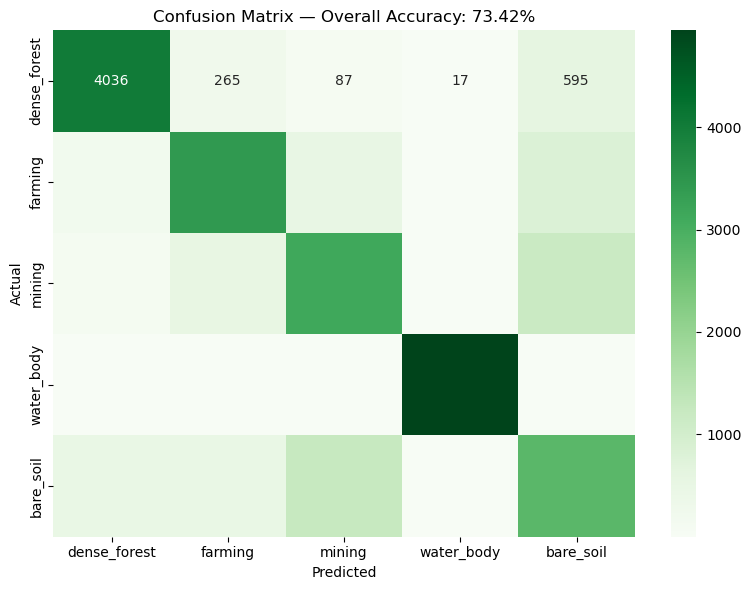

Saved → /Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events/output/confusion_matrix.png


In [49]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Accuracy Assessment
# ═══════════════════════════════════════════════════════════════

y_pred = rf.predict(X_test)

oa = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy : {oa * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = "d",
    cmap       = "Greens",
    xticklabels = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())],
    yticklabels = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]
)
plt.title(f"Confusion Matrix — Overall Accuracy: {oa*100:.2f}%")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}/confusion_matrix.png")




Balanced class distribution:
  class 0 (dense_forest): 20,000 pixels
  class 1 (farming): 20,000 pixels
  class 2 (mining): 20,000 pixels
  class 3 (water_body): 20,000 pixels
  class 4 (bare_soil): 20,000 pixels
Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   10.2s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.2s


Training complete ✓


[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    0.3s finished



Overall Accuracy : 72.65%

Classification Report:
              precision    recall  f1-score   support

dense_forest       0.82      0.81      0.81      5000
     farming       0.71      0.69      0.70      5000
      mining       0.61      0.62      0.62      5000
  water_body       0.99      0.99      0.99      5000
   bare_soil       0.51      0.52      0.51      5000

    accuracy                           0.73     25000
   macro avg       0.73      0.73      0.73     25000
weighted avg       0.73      0.73      0.73     25000



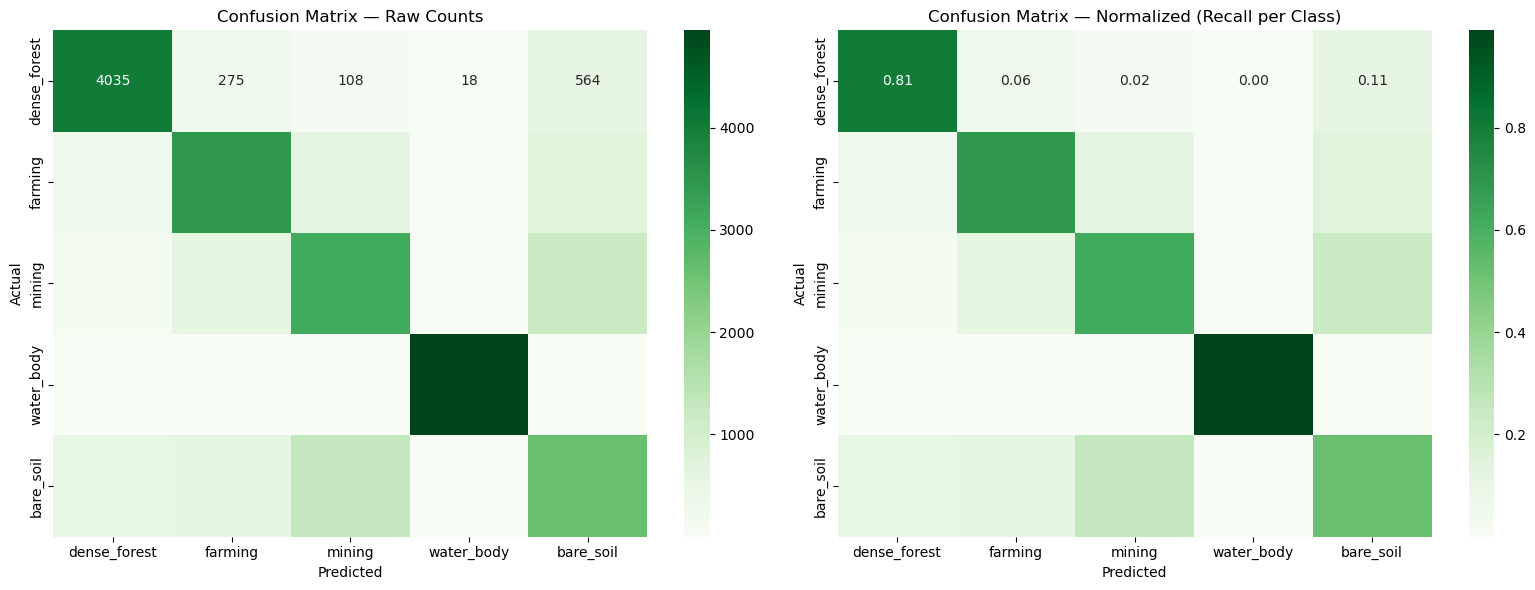

In [53]:
# ═══════════════════════════════════════════════════════════════
# CELL 4b — Undersample dominant classes to balance dataset
# ═══════════════════════════════════════════════════════════════
from collections import Counter

# Cap each class at max_per_class pixels
MAX_PER_CLASS = 20_000  # enough to learn, prevents dominance

balanced_X, balanced_y = [], []

for cls in np.unique(y):
    idx = np.where(y == cls)[0]
    
    if len(idx) > MAX_PER_CLASS:
        idx = np.random.choice(idx, MAX_PER_CLASS, replace=False)
    
    balanced_X.append(X[idx])
    balanced_y.append(y[idx])

X = np.vstack(balanced_X)
y = np.concatenate(balanced_y)

print("Balanced class distribution:")
for cls, cnt in Counter(y).items():
    print(f"  class {cls} ({CLASS_NAMES[cls]}): {cnt:,} pixels")


# ═══════════════════════════════════════════════════════════════
# CELL 6 — Train with class_weight="balanced" (Fix 2)
# ═══════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y          # ✅ ensures all classes appear in both splits
)

rf = RandomForestClassifier(
    n_estimators      = 300,
    max_depth         = 25,
    min_samples_split = 5,
    class_weight      = "balanced",   # ✅ Fix 2: penalizes misclassifying small classes
    n_jobs            = -1,
    random_state      = 42,
    verbose           = 1
)

print("Training Random Forest...")
rf.fit(X_train, y_train)
print("Training complete ✓")


# ═══════════════════════════════════════════════════════════════
# CELL 7 — Evaluate with macro avg focus (Fix 3)
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = rf.predict(X_test)

oa = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy : {oa * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]
))

# ✅ Normalize confusion matrix by row (true class) — shows recall per class
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=CLASS_NAMES.values(),
            yticklabels=CLASS_NAMES.values())
axes[0].set_title("Confusion Matrix — Raw Counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Normalized (recall view) — ✅ this is the honest view
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Greens", ax=axes[1],
            xticklabels=CLASS_NAMES.values(),
            yticklabels=CLASS_NAMES.values())
axes[1].set_title("Confusion Matrix — Normalized (Recall per Class)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_balanced.png", dpi=150)
plt.show()



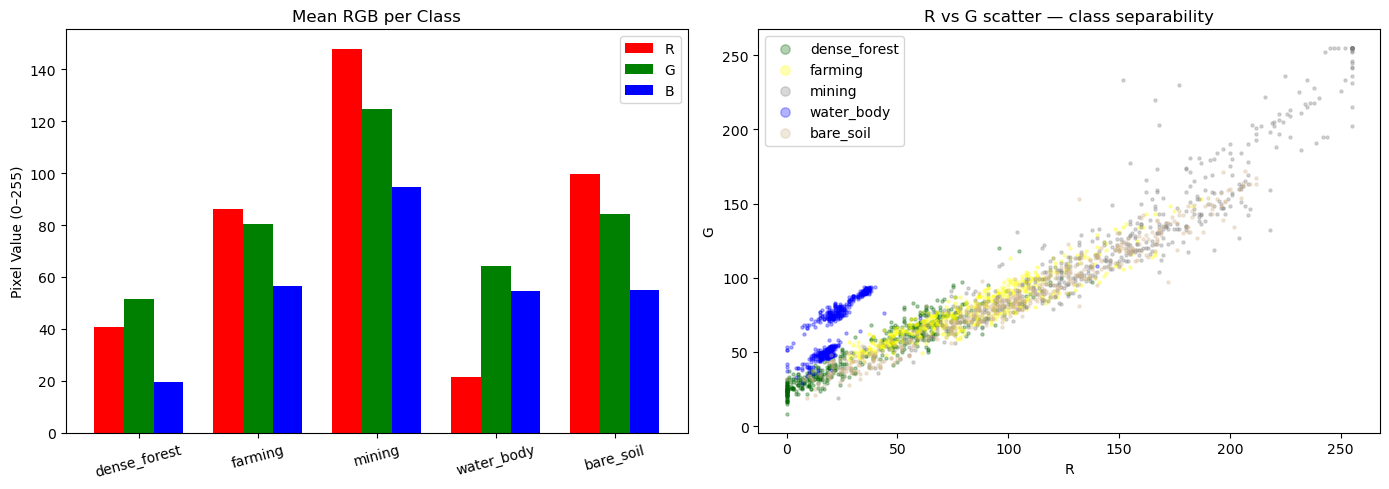

In [51]:
# ═══════════════════════════════════════════════════════════════
# DIAGNOSTIC — Plot mean RGB per class to see if they're separable
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Mean RGB bar chart per class ──
mean_rgb = {}
for cls in np.unique(y):
    idx = np.where(y == cls)[0]
    mean_rgb[cls] = X[idx, :3].mean(axis=0)  # only R,G,B

class_labels = [CLASS_NAMES[c] for c in sorted(mean_rgb.keys())]
r_vals = [mean_rgb[c][0] for c in sorted(mean_rgb.keys())]
g_vals = [mean_rgb[c][1] for c in sorted(mean_rgb.keys())]
b_vals = [mean_rgb[c][2] for c in sorted(mean_rgb.keys())]

x = np.arange(len(class_labels))
w = 0.25
axes[0].bar(x - w, r_vals, w, color="red",   label="R")
axes[0].bar(x,     g_vals, w, color="green", label="G")
axes[0].bar(x + w, b_vals, w, color="blue",  label="B")
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_labels, rotation=15)
axes[0].set_title("Mean RGB per Class")
axes[0].set_ylabel("Pixel Value (0–255)")
axes[0].legend()

# ── Plot 2: 2D scatter R vs G, colored by class ──
COLORS = {0:"darkgreen", 1:"yellow", 2:"grey", 3:"blue", 4:"tan"}
sample_size = 500

for cls in np.unique(y):
    idx = np.where(y == cls)[0]
    idx = np.random.choice(idx, min(sample_size, len(idx)), replace=False)
    axes[1].scatter(X[idx, 0], X[idx, 1],
                    c=COLORS[cls], label=CLASS_NAMES[cls],
                    alpha=0.3, s=5)

axes[1].set_xlabel("R")
axes[1].set_ylabel("G")
axes[1].set_title("R vs G scatter — class separability")
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_separability.png", dpi=150)
plt.show()

In [56]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — Predict LULC map on full image
# ═══════════════════════════════════════════════════════════════

def predict_lulc_map(tiff_path: Path, model, output_path: Path):
    """
    Run classifier on every pixel of the full GeoTIFF.
    Saves a classified GeoTIFF with class IDs as pixel values.
    """
    with rasterio.open(tiff_path) as src:
        profile = src.profile.copy()
        data    = src.read().astype(np.float32)  # (3, H, W)

    H, W = data.shape[1], data.shape[2]

    # Reshape to (H*W, 3)
    pixels = data.reshape(3, -1).T  # (N, 3)

    # Add same features used during training
    pixels = add_features(pixels)   # (N, 15)

    # Predict in batches to avoid memory issues on large TIFFs
    batch_size = 500_000
    predicted  = np.zeros(len(pixels), dtype=np.uint8)

    for start in range(0, len(pixels), batch_size):
        end               = min(start + batch_size, len(pixels))
        predicted[start:end] = model.predict(pixels[start:end])
        print(f"  → {end:,} / {len(pixels):,} pixels done...")

    # Reshape back to (H, W)
    lulc_map = predicted.reshape(H, W)

    # Save as GeoTIFF preserving CRS + transform
    out_profile = profile.copy()
    out_profile.update({"count": 1, "dtype": "uint8"})

    with rasterio.open(output_path, "w", **out_profile) as dst:
        dst.write(lulc_map[np.newaxis, :, :])

    print(f"LULC map saved → {output_path}")
    return lulc_map


# Predict on first_event image
print("Predicting LULC for first_event image...")
lulc_first = predict_lulc_map(
    TIFF_1,
    rf,
    OUTPUT_DIR / "lulc_first_event.tif"
)

# Predict on pre_event image
print("\nPredicting LULC for pre_event image...")
lulc_pre = predict_lulc_map(
    TIFF_2,
    rf,
    OUTPUT_DIR / "lulc_pre_event.tif"
)

Predicting LULC for first_event image...


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.5s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    3.2s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    5.3s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.


  → 500,000 / 4,027,226 pixels done...


[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.6s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    3.3s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    5.3s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.


  → 1,000,000 / 4,027,226 pixels done...


...

  → 3,000,000 / 4,027,226 pixels done...


[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.5s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    2.8s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    4.6s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.


  → 3,500,000 / 4,027,226 pixels done...


[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.5s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    2.9s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    4.7s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    0.2s finished


  → 4,000,000 / 4,027,226 pixels done...
  → 4,027,226 / 4,027,226 pixels done...
LULC map saved → /Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events/output/lulc_pre_event.tif


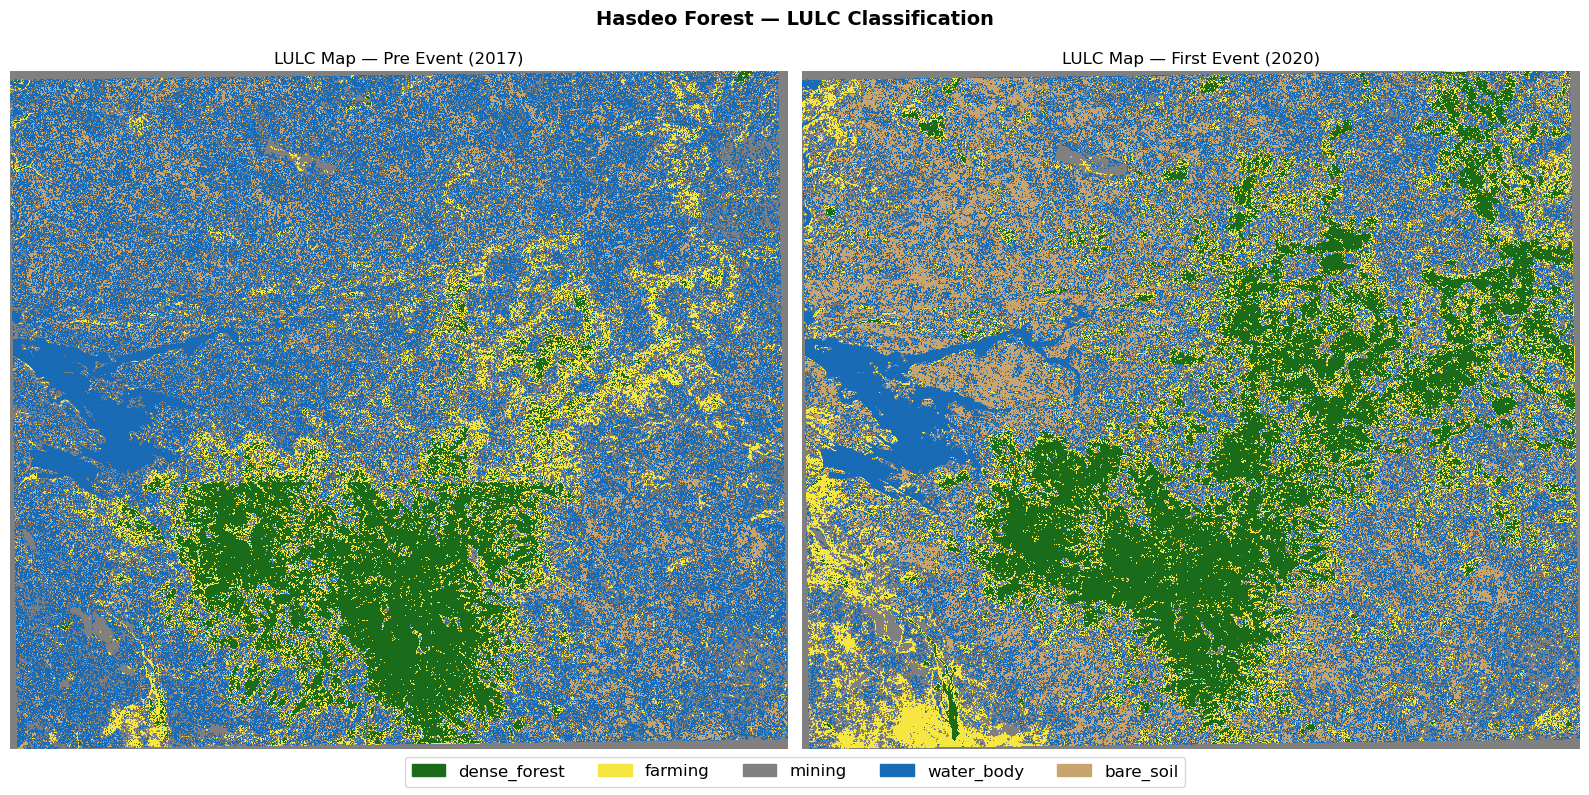

Saved → /Users/manjushwarkhairkar/GitHub/Urban-Leaf-Health-Monitoring/scripts/02_comparison_based_on_events/output/lulc_comparison.png


In [57]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — Visualize LULC Maps
# ═══════════════════════════════════════════════════════════════

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Colors per class
COLORS = {
    0: "#1a6b1a",   # Dense_Forest  → dark green
    1: "#f5e642",   # Agriculture   → yellow
    2: "#808080",   # Mining_Area   → grey
    3: "#1a6bb5",   # Water_Body    → blue
    4: "#c8a46e",   # Bare_Soil     → tan
}

cmap   = ListedColormap([COLORS[i] for i in sorted(COLORS.keys())])
legend = [Patch(color=COLORS[i], label=CLASS_NAMES[i]) for i in sorted(CLASS_NAMES.keys())]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(lulc_pre,   cmap=cmap, vmin=0, vmax=4)
axes[0].set_title("LULC Map — Pre Event (2017)")
axes[0].axis("off")

axes[1].imshow(lulc_first, cmap=cmap, vmin=0, vmax=4)
axes[1].set_title("LULC Map — First Event (2020)")
axes[1].axis("off")

fig.legend(handles=legend, loc="lower center", ncol=5, fontsize=12)
plt.suptitle("Hasdeo Forest — LULC Classification", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lulc_comparison.png", dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}/lulc_comparison.png")




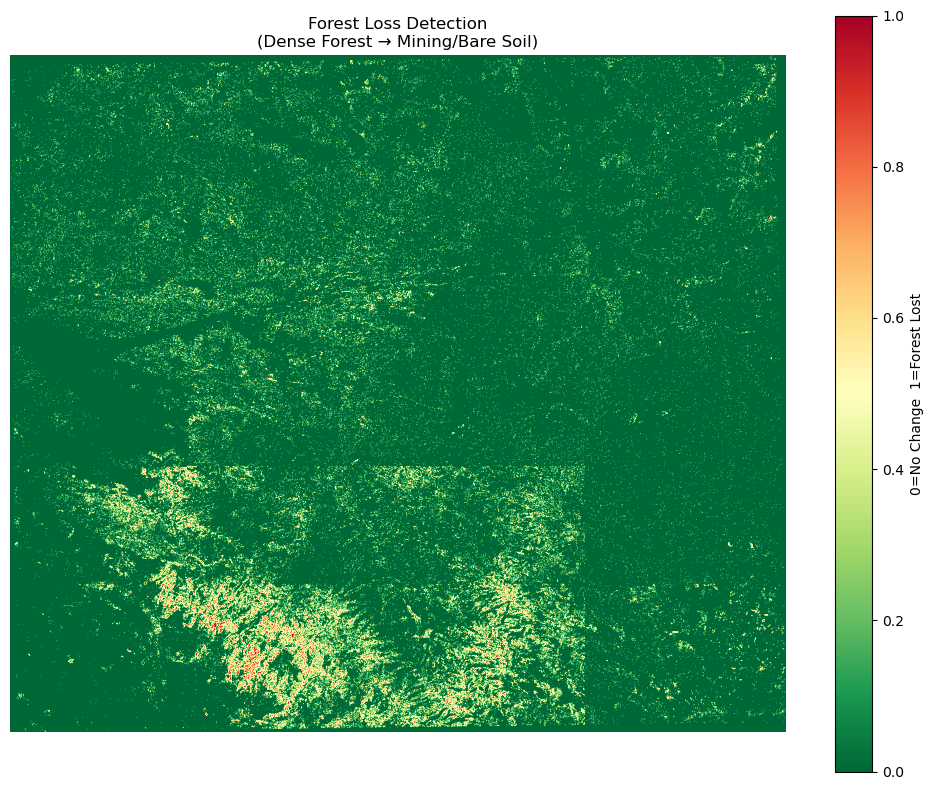


Forest Loss Statistics:
  Lost pixels     : 162,545
  Loss percentage : 4.04%
  Approx area     : 14629.05 km²  (at 30m resolution)


In [58]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — Change Detection (pre vs first_event)
# ═══════════════════════════════════════════════════════════════

if lulc_pre.shape == lulc_first.shape:
    # Forest loss = was Dense_Forest (0), now Mining (2) or Bare_Soil (4)
    forest_loss = ((lulc_pre == 0) & ((lulc_first == 2) | (lulc_first == 4)))

    plt.figure(figsize=(10, 8))
    plt.imshow(forest_loss, cmap="RdYlGn_r")
    plt.title("Forest Loss Detection\n(Dense Forest → Mining/Bare Soil)")
    plt.colorbar(label="0=No Change  1=Forest Lost")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "forest_loss.png", dpi=150)
    plt.show()

    total_pixels    = forest_loss.size
    lost_pixels     = forest_loss.sum()
    loss_percentage = (lost_pixels / total_pixels) * 100
    print(f"\nForest Loss Statistics:")
    print(f"  Lost pixels     : {lost_pixels:,}")
    print(f"  Loss percentage : {loss_percentage:.2f}%")
    print(f"  Approx area     : {lost_pixels * 0.09:.2f} km²  (at 30m resolution)")
else:
    print(" Images have different sizes — change detection skipped")
    print(f"   Pre event shape  : {lulc_pre.shape}")
    print(f"   First event shape: {lulc_first.shape}")